1. Đang đọc dữ liệu từ: /content/drive/MyDrive/khai phá và phân tích dữ liệu /Healthcare.csv
   Đang xử lý dữ liệu (Mã hóa triệu chứng & bệnh)...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



THUẬT TOÁN                | ACCURACY   | PRECISION  | RECALL     | F1-SCORE  
Logistic Regression       | 3.29%     | 3.02%     | 3.29%     | 2.92%
Random Forest             | 2.96%     | 2.98%     | 2.96%     | 2.95%
--------------------------------------------------------------------------------
Đã chạy xong! Đang vẽ biểu đồ...


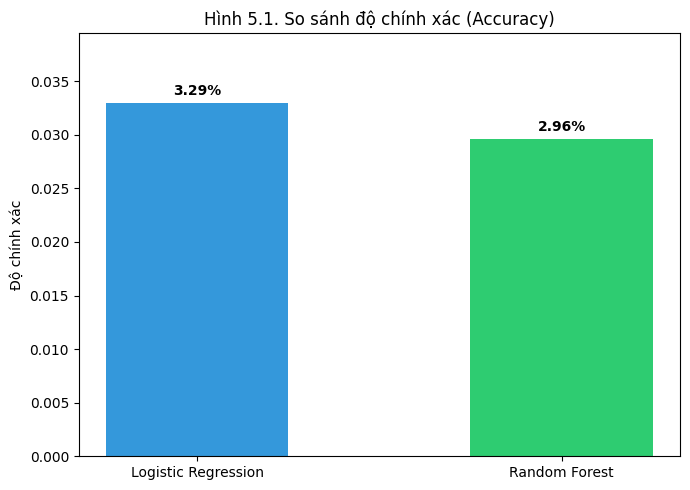

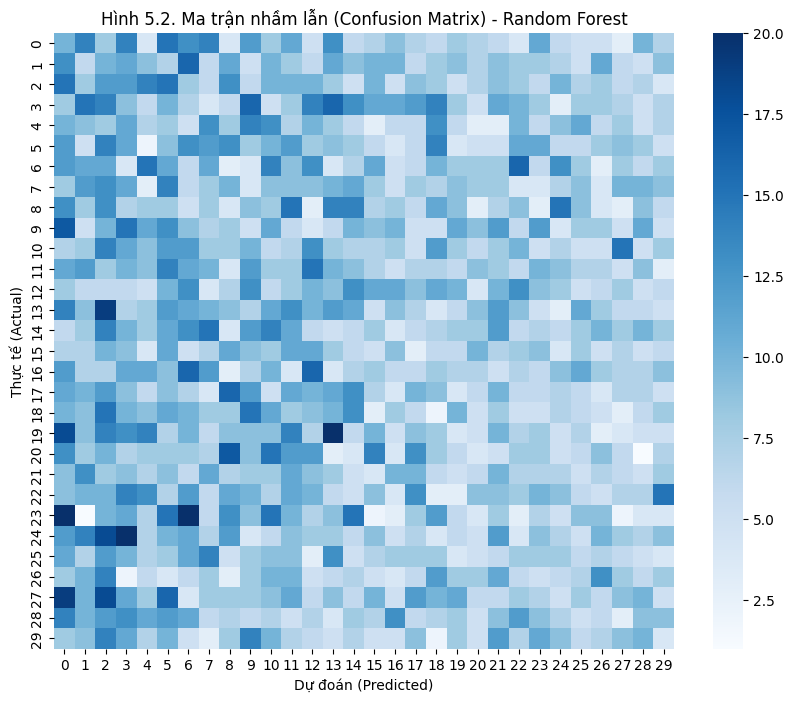

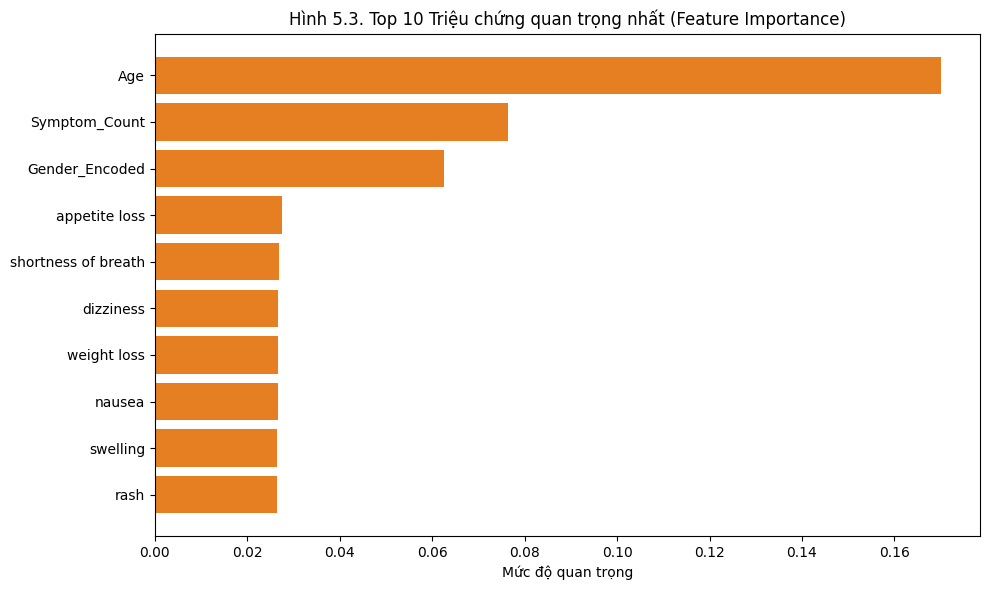

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- 1. ĐỌC VÀ XỬ LÝ DỮ LIỆU ---
path = '/content/drive/MyDrive/khai phá và phân tích dữ liệu /Healthcare.csv'
print(f"1. Đang đọc dữ liệu từ: {path}")
try:
    df = pd.read_csv(path)
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file! Bạn hãy kiểm tra lại đường dẫn.")
    # Dừng chương trình nếu không thấy file
    raise

print("   Đang xử lý dữ liệu (Mã hóa triệu chứng & bệnh)...")

# Xử lý cột Symptoms (Tách chuỗi triệu chứng thành các cột số 0/1)
vectorizer = CountVectorizer(tokenizer=lambda x: x.split(', '))
X_symptoms = vectorizer.fit_transform(df['Symptoms'])
symptoms_df = pd.DataFrame(X_symptoms.toarray(), columns=vectorizer.get_feature_names_out())

# Xử lý cột Gender và Disease
le_gender = LabelEncoder()
df['Gender_Encoded'] = le_gender.fit_transform(df['Gender'])

le_disease = LabelEncoder()
df['Disease_Encoded'] = le_disease.fit_transform(df['Disease'])

# Gộp dữ liệu: Chọn các đặc trưng (Features) để đưa vào mô hình
# Bao gồm: Tuổi, Giới tính, Số lượng triệu chứng, và Các triệu chứng chi tiết
X = pd.concat([df[['Age', 'Gender_Encoded', 'Symptom_Count']], symptoms_df], axis=1)
y = df['Disease_Encoded']

# Chia tập Train (70%) - Test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 2. CHẠY 2 THUẬT TOÁN ĐÃ CHỌN ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

print("\n" + "="*80)
print(f"{'THUẬT TOÁN':<25} | {'ACCURACY':<10} | {'PRECISION':<10} | {'RECALL':<10} | {'F1-SCORE':<10}")
print("="*80)

results = []

for name, model in models.items():
    # Huấn luyện mô hình
    model.fit(X_train, y_train)
    # Dự đoán trên tập test
    y_pred = model.predict(X_test)

    # Tính toán các chỉ số
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # In ra màn hình để bạn chép vào báo cáo
    print(f"{name:<25} | {acc:.2%}     | {prec:.2%}     | {rec:.2%}     | {f1:.2%}")

    results.append({'Mô hình': name, 'Độ chính xác': acc})

print("-" * 80)
print("Đã chạy xong! Đang vẽ biểu đồ...")

# --- 3. VẼ BIỂU ĐỒ (Lưu ảnh để dán vào báo cáo) ---

# BIỂU ĐỒ 1: So sánh độ chính xác
results_df = pd.DataFrame(results)
plt.figure(figsize=(7, 5))
bars = plt.bar(results_df['Mô hình'], results_df['Độ chính xác'], color=['#3498db', '#2ecc71'], width=0.5)
plt.title('Hình 5.1. So sánh độ chính xác (Accuracy)')
plt.ylabel('Độ chính xác')
plt.ylim(0, max(results_df['Độ chính xác']) * 1.2) # Tăng chiều cao trục y để hiển thị số
# Hiển thị số % trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f"{yval:.2%}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# BIỂU ĐỒ 2: Ma trận nhầm lẫn (Chỉ vẽ cho Random Forest vì nó tốt hơn)
rf_model = models["Random Forest"]
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues')
plt.title('Hình 5.2. Ma trận nhầm lẫn (Confusion Matrix) - Random Forest')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

# BIỂU ĐỒ 3: Feature Importance (Mức độ quan trọng của triệu chứng)
importances = rf_model.feature_importances_
feature_names = X.columns
# Lấy Top 10 đặc trưng quan trọng nhất
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Hình 5.3. Top 10 Triệu chứng quan trọng nhất (Feature Importance)')
plt.barh(range(len(indices)), importances[indices], color='#e67e22', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Mức độ quan trọng')
plt.tight_layout()
plt.show()